In [1]:
# ============================================================
#   Auto‑Encoder Similarity Notebook for One Shape Folder
# ============================================================

# 0️⃣ Install / import packages (versions pinned for Colab)
!pip install -q "tensorflow==2.18.0" "pandas==2.1.4" "plotly>=5.19.0,<6" pillow scikit-learn

import os, io, base64, random, math
from pathlib import Path

import numpy as np
import plotly.express as px
import tensorflow as tf
from tensorflow.keras import layers, models
from PIL import Image
from sklearn.decomposition import PCA
from IPython.display import HTML, display


In [2]:
#@title 1️⃣ Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
SHAPES_ROOT = "/content/drive/MyDrive/shapes"  # <‑‑ adjust if needed

shape_folder   = "shape4"   #@param ["shape3","shape4","shape5","shape6"]
batch_size     = 32         #@param {type:"integer"}
epochs         = 50         #@param {type:"integer"}  # Increased from 40
beta           = 1.5        #@param {type:"number"}   # NEW: β parameter for KL loss weighting
learning_rate  = 0.001      #@param {type:"number"}   # NEW: Learning rate control
plot_latent_2D = True       #@param {type:"boolean"}

shape_path = Path(SHAPES_ROOT) / shape_folder
assert shape_path.is_dir(), f"{shape_path} not found"

print(f"▶ Using folder: {shape_path}")
print(f"▶ β (beta) parameter: {beta}")
print(f"▶ Learning rate: {learning_rate}")


▶ Using folder: /content/drive/MyDrive/shapes/shape4
▶ β (beta) parameter: 1.5
▶ Learning rate: 0.001


In [39]:
#@title 3️⃣ Load images (200×200 grayscale, no resizing, invert pixels)
def load_png(path):
    img = Image.open(path).convert("L")                 # grayscale
    arr = 1.0 - (np.array(img, dtype=np.float32) / 255) # invert: stroke→0
    return arr[..., None]                               # add channels dim

all_pngs = sorted([p for p in shape_path.iterdir() if p.suffix.lower()==".png"])
assert all_pngs, "No PNG images found."

ref_name = f"original{shape_folder[-1]}.png"
ref_path = shape_path / ref_name
assert ref_path.exists(), f"{ref_name} missing"
drawing_paths = [p for p in all_pngs if p.name != ref_name]

print(f"▶ Loaded {len(drawing_paths)} drawings (+1 reference)")

ref_img = load_png(ref_path)
x_imgs  = np.stack([load_png(p) for p in drawing_paths], axis=0)
print("Tensor shape:", x_imgs.shape)

▶ Loaded 895 drawings (+1 reference)
Tensor shape: (895, 200, 200, 1)


In [40]:
#@title 4️⃣ Define & compile convolutional **VAE** (binary‑Xent + KL)


import tensorflow as tf
from tensorflow.keras import layers, models, backend as K

# ------------------------------------------------------------------
img_h = 200        # image height   (do not resize your data)
img_w = 200        # image width
latent_dim = 128   # size of the latent vector
# ------------------------------------------------------------------

# ---------- Encoder ----------
def build_encoder():
    inp = layers.Input(shape=(img_h, img_w, 1))

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPool2D()(x)                          # 100×100
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPool2D()(x)                          # 50×50
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.Flatten()(x)

    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_logv = layers.Dense(latent_dim, name="z_logv")(x)

    return models.Model(inp, [z_mean, z_logv], name="encoder")

# ---------- Decoder ----------
def build_decoder():
    dec_in = layers.Input(shape=(latent_dim,))
    y = layers.Dense((img_h // 4) * (img_w // 4) * 128, activation="relu")(dec_in)  # 50×50×128
    y = layers.Reshape((img_h // 4, img_w // 4, 128))(y)                             # 50×50×128
    y = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(y)  # 100×100
    y = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(y)  # 200×200
    out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(y)
    return models.Model(dec_in, out, name="decoder")

# ---------- Improved VAE class with β parameter and validation ----------
class BetaVAE(tf.keras.Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta  # β parameter for KL loss weighting

        # Metrics for tracking
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def reparameterize(self, z_mean, z_logv):
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_logv) * eps

    def call(self, inputs):
        z_mean, z_logv = self.encoder(inputs)
        z = self.reparameterize(z_mean, z_logv)
        reconstruction = self.decoder(z)
        return reconstruction

    def compute_loss(self, x):
        """Compute VAE loss components"""
        z_mean, z_logv = self.encoder(x)
        z = self.reparameterize(z_mean, z_logv)
        reconstruction = self.decoder(z)

        # Reconstruction loss (binary cross-entropy)
        recon_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(x, reconstruction)
        ) * (img_h * img_w)

        # KL divergence loss
        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_logv - tf.square(z_mean) - tf.exp(z_logv)
        )

        # Total loss with β weighting
        total_loss = recon_loss + self.beta * kl_loss

        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        # Handle the case where data is (x, y) tuple - we only need x for VAE
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self.compute_loss(x)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        """Validation step - now works properly!"""
        # Handle the case where data is (x, y) tuple - we only need x for VAE
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        total_loss, recon_loss, kl_loss = self.compute_loss(x)

        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# ---------- Build and compile improved VAE ----------
encoder = build_encoder()
decoder = build_decoder()
vae = BetaVAE(encoder, decoder, beta=beta)

# Compile with custom learning rate and dummy loss
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
vae.compile(optimizer=optimizer, loss=lambda y_true, y_pred: 0.0)

encoder.summary()
print(f"\n✅ β-VAE initialized with β={beta}, learning_rate={learning_rate}")


#@title 5️⃣ Train improved β-VAE (UPDATED)
print(f"🚀 Training β-VAE for {epochs} epochs...")
print(f"📊 Batch size: {batch_size}")
print(f"🎛️ β parameter: {beta} (higher β = more regularization)")
print(f"📈 Learning rate: {learning_rate}")
print("-" * 50)

history = vae.fit(
    x_imgs, x_imgs,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.15,  # Increased validation split
    verbose=2
)

print(f"\n✅ Training completed!")
print(f"📉 Final training loss: {history.history['loss'][-1]:.2f}")
print(f"📉 Final validation loss: {history.history['val_loss'][-1]:.2f}")

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 200, 200,  │        320 │ input_layer_16[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 100, 100,  │          0 │ conv2d_32[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 100, 100,  │     18,496 │ max_pooling2d_16… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_17    │ (None, 50, 50,    │          0 │ conv2d_33[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 50, 50,    │     73,856 │ max_pooling2d_17… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_10          │ (None, 320000)    │          0 │ conv2d_34[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 128)       │ 40,960,128 │ flatten_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_logv (Dense)      │ (None, 128)       │ 40,960,128 │ flatten_10[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 82,012,928 (312.85 MB)

 Trainable params: 82,012,928 (312.85 MB)

 Non-trainable params: 0 (0.00 B)


✅ β-VAE initialized with β=1.5, learning_rate=0.001
🚀 Training β-VAE for 50 epochs...
📊 Batch size: 32
🎛️ β parameter: 1.5 (higher β = more regularization)
📈 Learning rate: 0.001
--------------------------------------------------
Epoch 1/50
24/24 - 9s - 373ms/step - kl_loss: 547.6163 - loss: 8685.1963 - reconstruction_loss: 7863.7720 - val_kl_loss: 4.2953 - val_loss: 4526.8633 - val_reconstruction_loss: 4520.4204
Epoch 2/50
24/24 - 1s - 25ms/step - kl_loss: 3.4027 - loss: 4110.2168 - reconstruction_loss: 4105.1133 - val_kl_loss: 2.6765 - val_loss: 4379.7095 - val_reconstruction_loss: 4375.6943
Epoch 3/50
24/24 - 1s - 24ms/step - kl_loss: 2.9068 - loss: 4035.1252 - reconstruction_loss: 4030.7646 - val_kl_loss: 2.5384 - val_loss: 4346.3613 - val_reconstruction_loss: 4342.5537
Epoch 4/50
24/24 - 1s - 24ms/step - kl_loss: 2.8536 - loss: 3999.7092 - reconstruction_loss: 3995.4294 - val_kl_loss: 2.1692 - val_loss: 4391.9541 - val_reconstruction_loss: 4388.7002
Epoch 5/50
24/24 - 1s - 25ms/s

In [41]:
#@title 5️⃣ Train VAE
history = vae.fit(
    x_imgs, x_imgs,
    epochs   = epochs,
    batch_size = batch_size,
    shuffle  = True,
    validation_split = 0.1,
    verbose = 2
)

Epoch 1/50
26/26 - 3s - 134ms/step - kl_loss: 6.4434 - loss: 889.6497 - reconstruction_loss: 879.9846 - val_kl_loss: 6.0870 - val_loss: 3568.1855 - val_reconstruction_loss: 3559.0549
Epoch 2/50
26/26 - 1s - 24ms/step - kl_loss: 7.5549 - loss: 824.3671 - reconstruction_loss: 813.0348 - val_kl_loss: 6.5210 - val_loss: 3605.2405 - val_reconstruction_loss: 3595.4590
Epoch 3/50
26/26 - 1s - 23ms/step - kl_loss: 7.3791 - loss: 851.8418 - reconstruction_loss: 840.7730 - val_kl_loss: 7.5579 - val_loss: 3982.8503 - val_reconstruction_loss: 3971.5134
Epoch 4/50
26/26 - 1s - 24ms/step - kl_loss: 52.4423 - loss: 5968.9043 - reconstruction_loss: 5890.2417 - val_kl_loss: 50.1155 - val_loss: 5014.7358 - val_reconstruction_loss: 4939.5630
Epoch 5/50
26/26 - 1s - 23ms/step - kl_loss: 24.6179 - loss: 4376.7705 - reconstruction_loss: 4339.8433 - val_kl_loss: 13.9887 - val_loss: 4892.2974 - val_reconstruction_loss: 4871.3145
Epoch 6/50
26/26 - 1s - 23ms/step - kl_loss: 13.7491 - loss: 4174.1943 - reconstr

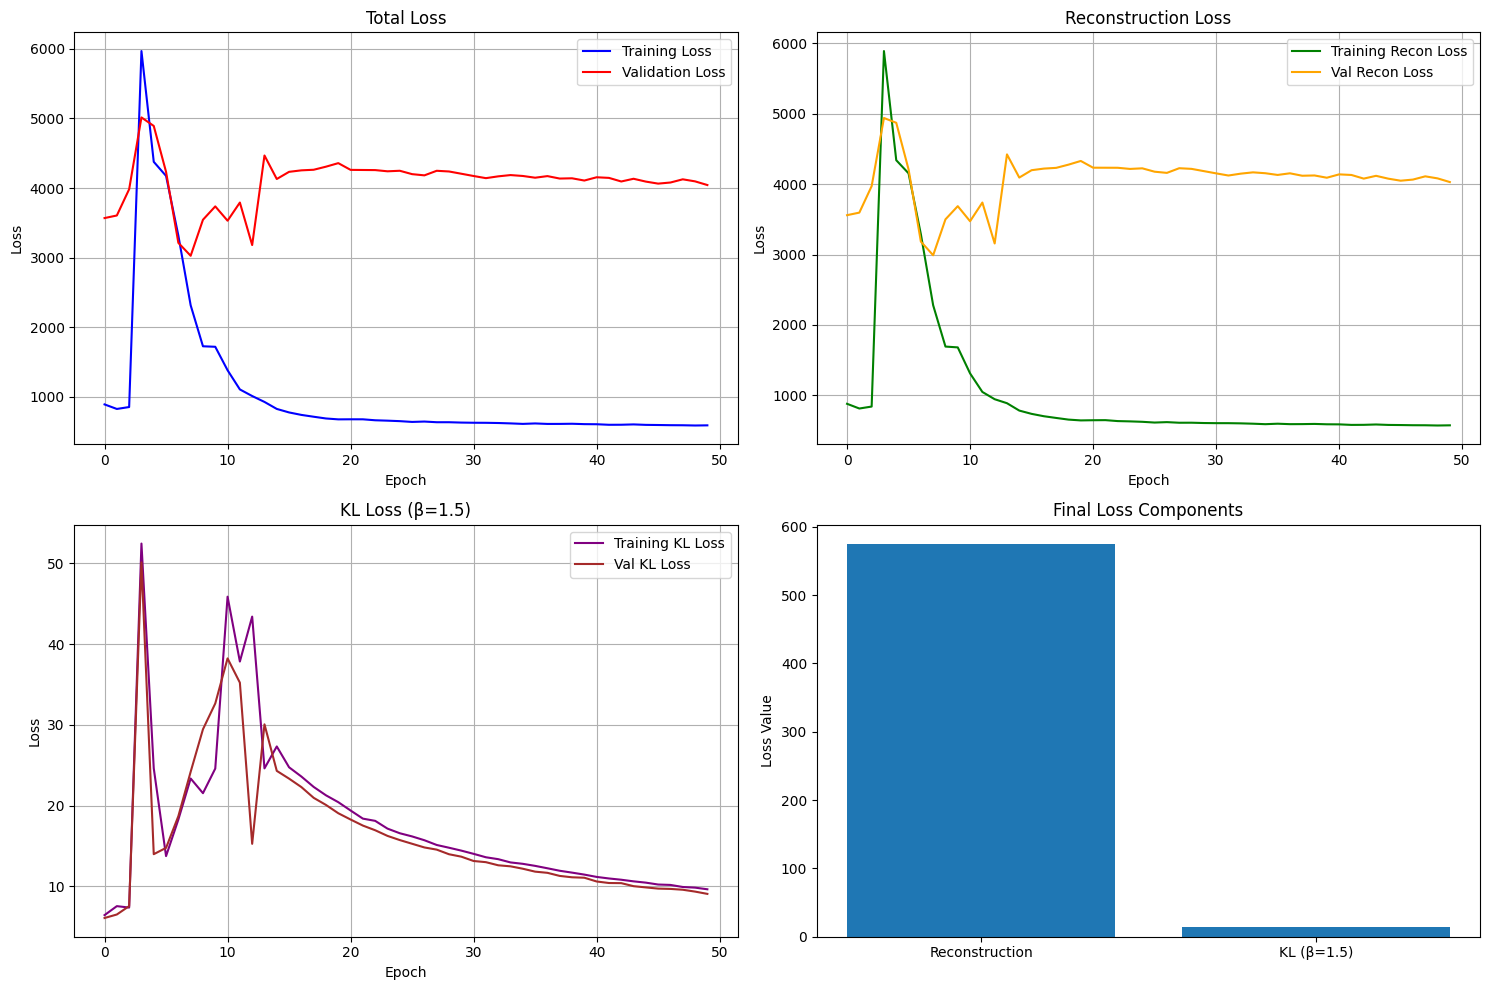


📊 Loss Analysis:
   • Final reconstruction loss: 574.22
   • Final KL loss: 9.64
   • Final weighted KL loss (β×KL): 14.46
   • Reconstruction vs KL ratio: 39.70


In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot total loss
axes[0,0].plot(history.history['loss'], label='Training Loss', color='blue')
axes[0,0].plot(history.history['val_loss'], label='Validation Loss', color='red')
axes[0,0].set_title('Total Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True)

# Plot reconstruction loss
axes[0,1].plot(history.history['reconstruction_loss'], label='Training Recon Loss', color='green')
axes[0,1].plot(history.history['val_reconstruction_loss'], label='Val Recon Loss', color='orange')
axes[0,1].set_title('Reconstruction Loss')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()
axes[0,1].grid(True)

# Plot KL loss
axes[1,0].plot(history.history['kl_loss'], label='Training KL Loss', color='purple')
axes[1,0].plot(history.history['val_kl_loss'], label='Val KL Loss', color='brown')
axes[1,0].set_title(f'KL Loss (β={beta})')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()
axes[1,0].grid(True)

# Plot loss ratio
recon_final = history.history['reconstruction_loss'][-1]
kl_final = history.history['kl_loss'][-1]
axes[1,1].bar(['Reconstruction', f'KL (β={beta})'], [recon_final, beta * kl_final])
axes[1,1].set_title('Final Loss Components')
axes[1,1].set_ylabel('Loss Value')

plt.tight_layout()
plt.show()

print(f"\n📊 Loss Analysis:")
print(f"   • Final reconstruction loss: {recon_final:.2f}")
print(f"   • Final KL loss: {kl_final:.2f}")
print(f"   • Final weighted KL loss (β×KL): {beta * kl_final:.2f}")
print(f"   • Reconstruction vs KL ratio: {recon_final/(beta * kl_final):.2f}")

In [43]:
#@title 6️⃣ Embed drawings & compute distances (use encoder mean)
# encoder now returns (z_mean, z_logv, z_sample)
latent_ref   = encoder(np.expand_dims(ref_img,0))[0].numpy().reshape(-1)
latent_draws = encoder.predict(x_imgs, batch_size=batch_size)[0].reshape(len(x_imgs), -1)
dists = np.linalg.norm(latent_draws - latent_ref, axis=1)

order         = np.argsort(dists)
sorted_paths  = [drawing_paths[i] for i in order]
sorted_dists  = dists[order]

print("Closest 5 drawings:")
for p, d in zip(sorted_paths[:5], sorted_dists[:5]):
    print(f"{p.name:>15} : dist={d:.4f}")


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Closest 5 drawings:
      11201.png : dist=24.6641
      10309.png : dist=25.8344
      10059.png : dist=28.2284
      10465.png : dist=28.7698
       7758.png : dist=29.9962


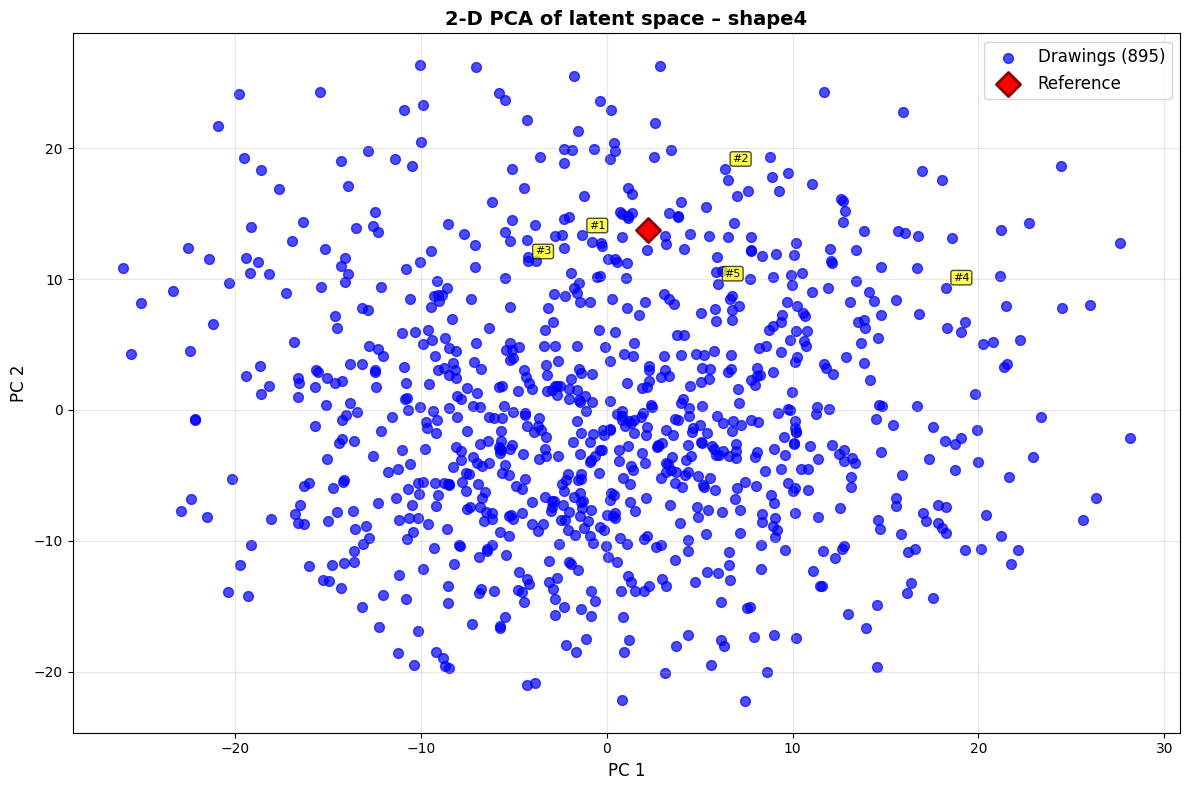

🖼️ IMAGE BROWSER:
Reference Image:


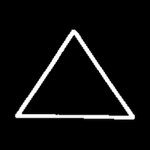


🎯 Top 10 Most Similar Drawings (out of 895):

#1: 11201.png (Distance: 24.6641)


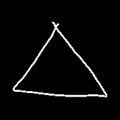


#2: 10309.png (Distance: 25.8344)


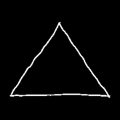


#3: 10059.png (Distance: 28.2284)


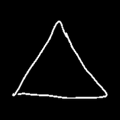


#4: 10465.png (Distance: 28.7698)


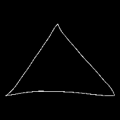


#5: 7758.png (Distance: 29.9962)


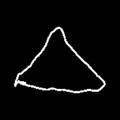


#6: 10367.png (Distance: 30.2078)


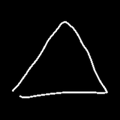


#7: 10244.png (Distance: 30.5512)


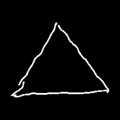


#8: 10739.png (Distance: 31.7092)


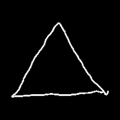


#9: 10464.png (Distance: 32.1542)


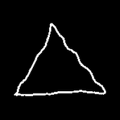


#10: 10317.png (Distance: 32.5241)


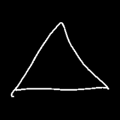


📈 SIMILARITY STATISTICS:
Mean distance: 50.5773
Std distance: 6.8286
Min distance: 24.6641
Max distance: 78.7161
Median distance: 51.0453


In [44]:
# Simple matplotlib version (always works in Colab)
if plot_latent_2D:
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA
    from IPython.display import display

    # ---------- reduce to 2‑D ----------
    all_lat = np.vstack([latent_ref.reshape(1, -1), latent_draws])
    lat2    = PCA(n_components=2).fit_transform(all_lat)
    xs, ys  = lat2[:, 0], lat2[:, 1]

    # Create matplotlib plot
    plt.figure(figsize=(12, 8))

    # Plot drawings
    plt.scatter(xs[1:], ys[1:], c='blue', s=50, alpha=0.7, label=f'Drawings ({len(drawing_paths)})')

    # Plot reference
    plt.scatter(xs[0], ys[0], c='red', s=150, marker='D', label='Reference', edgecolors='darkred', linewidth=2)

    # Customize plot
    plt.xlabel('PC 1', fontsize=12)
    plt.ylabel('PC 2', fontsize=12)
    plt.title(f'2-D PCA of latent space – {shape_folder}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)

    # Add some annotations for closest points
    closest_indices = np.argsort(dists)[:5]
    for i, idx in enumerate(closest_indices):
        plt.annotate(f'#{i+1}',
                    (xs[idx+1], ys[idx+1]),
                    xytext=(5, 5),
                    textcoords='offset points',
                    fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7))

    plt.tight_layout()
    plt.show()

    # Create a simple image browser
    print("🖼️ IMAGE BROWSER:")
    print("Reference Image:")
    ref_img_pil = Image.open(ref_path).convert("RGB").resize((150, 150))
    display(ref_img_pil)

    print(f"\n🎯 Top 10 Most Similar Drawings (out of {len(drawing_paths)}):")
    for i, (path, dist) in enumerate(zip(sorted_paths[:10], sorted_dists[:10])):
        print(f"\n#{i+1}: {path.name} (Distance: {dist:.4f})")
        img_pil = Image.open(path).convert("RGB").resize((120, 120))
        display(img_pil)

    # Show some statistics
    print(f"\n📈 SIMILARITY STATISTICS:")
    print(f"Mean distance: {np.mean(dists):.4f}")
    print(f"Std distance: {np.std(dists):.4f}")
    print(f"Min distance: {np.min(dists):.4f}")
    print(f"Max distance: {np.max(dists):.4f}")
    print(f"Median distance: {np.median(dists):.4f}")

▶ HTML gallery written to: /content/drive/MyDrive/shapes/shape4/shape4_vae_similarity.html



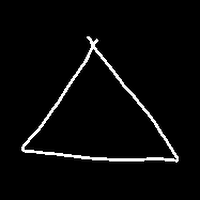
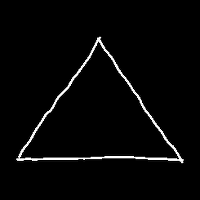
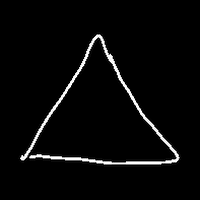
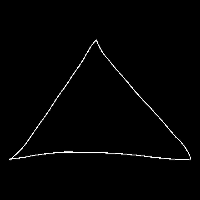
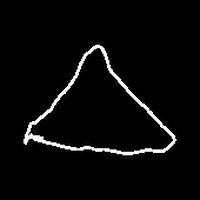
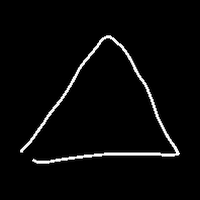
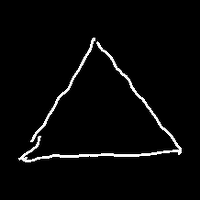
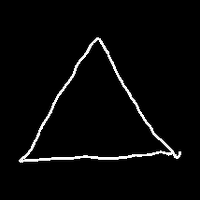
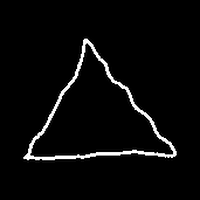
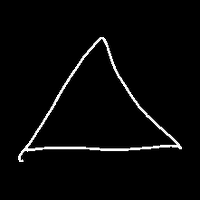
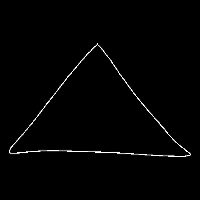
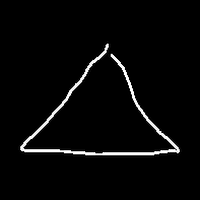
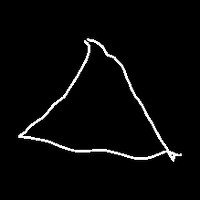
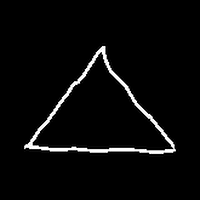
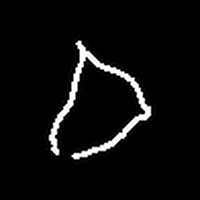
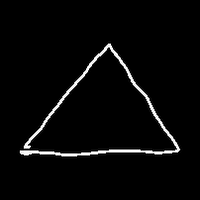
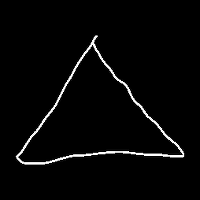
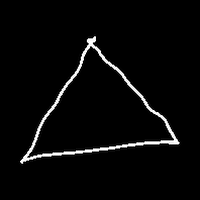
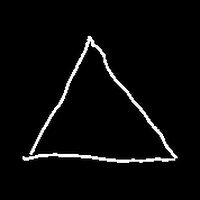
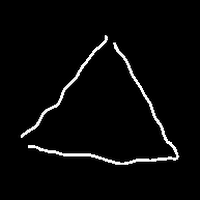
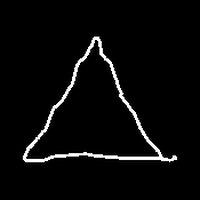
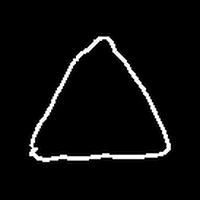
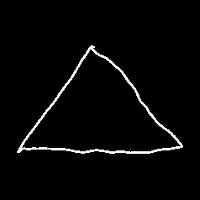
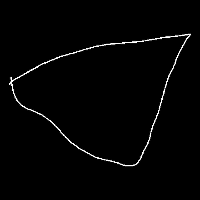
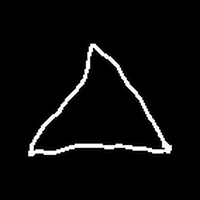
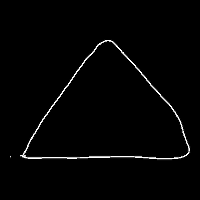
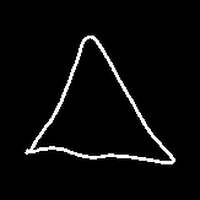
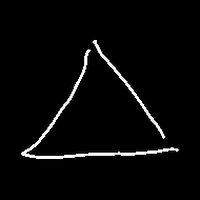

In [45]:

#@title 8️⃣ Create ordered HTML gallery (10 images per row)
html_rows = []
for i, (p,d) in enumerate(zip(sorted_paths, sorted_dists)):
    if i % 10 == 0:
        html_rows.append("<tr>")
    with open(p,'rb') as f: b64 = base64.b64encode(f.read()).decode()
    html_rows.append(
        f"<td style='text-align:center;font-size:10px'>"
        f"<img src='data:image/png;base64,{b64}' width='96'><br>"
        f"{p.name}<br>dist={d:.4f}</td>"
    )
    if i % 10 == 9:
        html_rows.append("</tr>")
if not html_rows[-1].startswith("</tr>"):
    html_rows.append("</tr>")

html_page = f"""
<html><head><meta charset='utf-8'>
<title>{shape_folder} – similarity</title></head>
<body>
<h2>Similarity ranking – {shape_folder}</h2>
<table border=0 cellspacing=4 cellpadding=4>
{''.join(html_rows)}
</table></body></html>
"""

out_path = shape_path / f"{shape_folder}_vae_similarity.html"
with open(out_path,"w") as f: f.write(html_page)
print("▶ HTML gallery written to:", out_path)

display(HTML("<h4>Preview first 30 entries</h4>"+''.join(html_rows[:33])))



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step


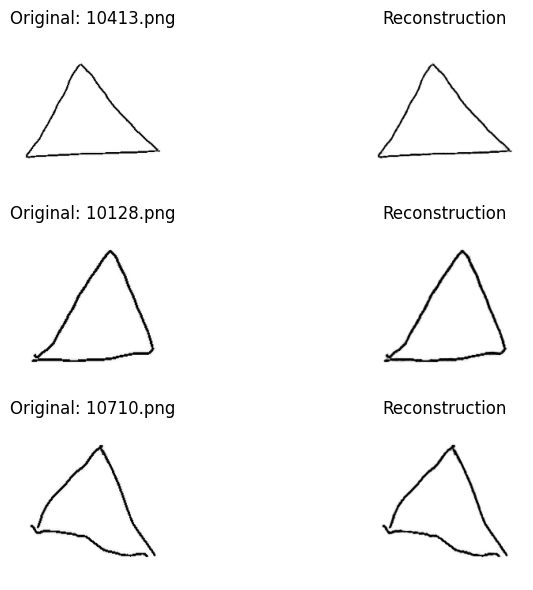

In [46]:
#@title 9️⃣ Reconstruction demo – 3 random drawings
sample_idx = np.random.choice(len(drawing_paths), 3, replace=False)
recons = vae.predict(x_imgs[sample_idx], batch_size=3)

import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
for i, idx in enumerate(sample_idx):
    # original
    plt.subplot(3,2,2*i+1)
    plt.imshow(x_imgs[idx].squeeze(), cmap='gray')
    plt.axis('off'); plt.title(f"Original: {drawing_paths[idx].name}")
    # reconstruction
    plt.subplot(3,2,2*i+2)
    plt.imshow(recons[i].squeeze(), cmap='gray')
    plt.axis('off'); plt.title("Reconstruction")
plt.tight_layout(); plt.show()
